<a href="https://colab.research.google.com/github/EduardoShoiti/pos-tech-ai-scientist/blob/main/Fase1/Estatistica_essencial_ds/Pos_Tech_Estatistica_DS_Aula1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 😊☹️ **Case: análise de NPS com estatística**

O Net Promoter Score (NPS) é um dos principais indicadores de satisfação e lealdade dos clientes de um banco. Ele ajuda a entender se os clientes estão satisfeitos o suficiente para recomendar os serviços da instituição, um fator essencial para identificar pontos de melhoria, reduzir churn e direcionar estratégias de relacionamento.

No entanto, existe um ponto de atenção importante: nem todos os clientes respondem à pesquisa. Isso pode gerar **viés de resposta**, pois a opinião disponível representa apenas quem decidiu responder (muitas vezes clientes muito satisfeitos ou insatisfeitos extremos, o que pode distorcer a visão real da base).

Para mitigar esse risco e trazer mais robustez à análise, aplicamos **inferência estatística**: selecionamos uma **amostra aleatória das respostas e calculamos um intervalo de confiança**, permitindo **estimar a média de NPS da população de respondentes com incerteza controlada**.

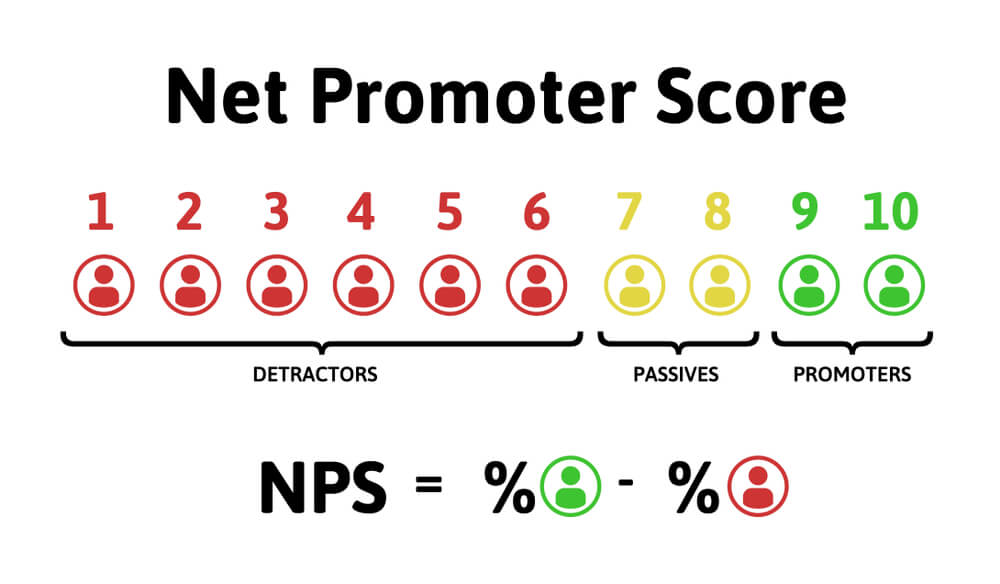

## Conhecendo a base de dados 🔎

In [1]:
import pandas as pd

df = pd.read_csv('NPStimeseries.csv')
df.head()

,ID,Market,Survey date,Customer Name,Month,Quarter,NPS
0,1000,US,01/09/2021,Krista Richards,9,3,10
1,1001,MEX,07/11/2021,Monica King,11,4,9
2,1002,UK,25/12/2021,Ricky Armstrong,12,4,0
3,1003,UK,01/10/2021,Andrea Foley,10,4,10
4,1004,UK,01/03/2021,Jerry Garcia,3,1,8


In [2]:
df.shape

(5000, 7)

## Analisando a qualidade dos dados 🧹

In [3]:
import numpy as np
from scipy import stats

Avaliando se temos dados nulos. Dados inválidos ou NAs distorcem média, desvio e IC.

In [4]:
df.isnull().sum()

,0
ID,0
Market,0
Survey date,0
Customer Name,0
Month,0
Quarter,0
NPS,0


## Construindo uma amostra aleatória 🎲

In [5]:
np.random.seed(42)
sample = df.sample(n=1000, replace=False)

In [6]:
df.describe() # população

,ID,Month,Quarter,NPS
count,5000.000000,5000.000000,5000.000000,5000.00000
mean,3499.500000,6.496000,2.503000,6.84120
std,1443.520003,3.424899,1.108078,3.49228
min,1000.000000,1.000000,1.000000,0.00000
25%,2249.750000,4.000000,2.000000,5.00000
50%,3499.500000,7.000000,3.000000,8.00000
75%,4749.250000,9.000000,3.000000,10.00000
max,5999.000000,12.000000,4.000000,10.00000


In [7]:
sample.describe() # amostra

,ID,Month,Quarter,NPS
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,3466.656000,6.558000,2.531000,6.939000
std,1475.210263,3.407087,1.104653,3.455028
min,1008.000000,1.000000,1.000000,0.000000
25%,2147.750000,4.000000,2.000000,5.000000
50%,3501.500000,7.000000,3.000000,8.000000
75%,4718.250000,9.000000,3.000000,10.000000
max,5998.000000,12.000000,4.000000,10.000000


In [8]:
# Statistics
sample_mean = sample['NPS'].mean()
sample_std = sample['NPS'].std(ddof=1)  # significa desvio padrão amostral, usado quando você está trabalhando com uma amostra e não com a população inteira
n = len(sample)

In [9]:
sample_mean

np.float64(6.939)

<Axes: >

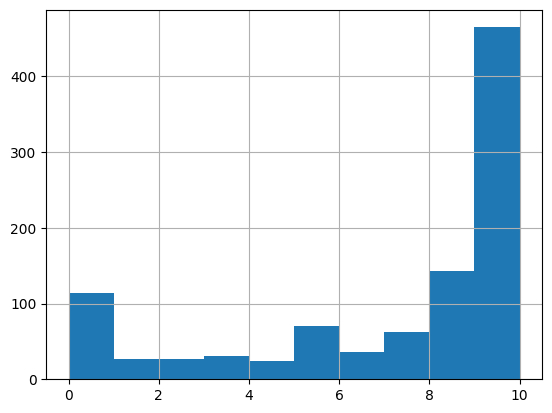

In [10]:
sample['NPS'].hist()

## **Verificar normalidade**

### Shapiro-Wilk
Validando se os dados segue uma distribuição normal.
Use Shapiro-Wilk!
- Objetivo: verificar se os dados seguem uma distribuição normal (formato de sino).

Ele testa a hipótese:

* H0 (nula): os dados são normais

* H1 (alternativa): os dados não são normais

p-value > 0.05 -> não rejeita normalidade ✅

p-value < 0.05 -> rejeita normalidade ❌

### Q-Q Plot (Quantile-Quantile Plot)

Objetivo: visualizar se os dados parecem normais.

* Se os pontos ficam próximos da linha, parece normal ✅

* Se os pontos desviam muito, não parece normal ❌

In [11]:
import matplotlib.pyplot as plt
from scipy.stats import shapiro, probplot

def analyze_distribution_and_ci(data, confidence=0.95, n_bootstrap=5000):
    data = np.array(data)
    n = len(data)
    mean = np.mean(data)

    # Teste Shapiro-Wilk para normalidade
    shapiro_stat, shapiro_p = shapiro(data)

    # Plot histograma
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.hist(data, bins=10)
    plt.title("Histograma")

    # QQ-Plot
    plt.subplot(1, 2, 2)
    probplot(data, dist="norm", plot=plt)
    plt.title("QQ-Plot")

    plt.show()

    # Bootstrap CI
    alpha = 1 - confidence
    boot_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        boot_means.append(np.mean(sample))

    lower = np.percentile(boot_means, (alpha/2) * 100)
    upper = np.percentile(boot_means, (1 - alpha/2) * 100)
    ci_bootstrap = (lower, upper)

    print(f"Média da amostra: {mean:.3f}")
    print(f"IC Bootstrap ({confidence*100:.0f}%): {ci_bootstrap[0]:.3f}  a  {ci_bootstrap[1]:.3f}")
    print(f"p-valor Shapiro-Wilk: {shapiro_p:.4f} {'(normal)' if shapiro_p>0.05 else '(não normal)'}")


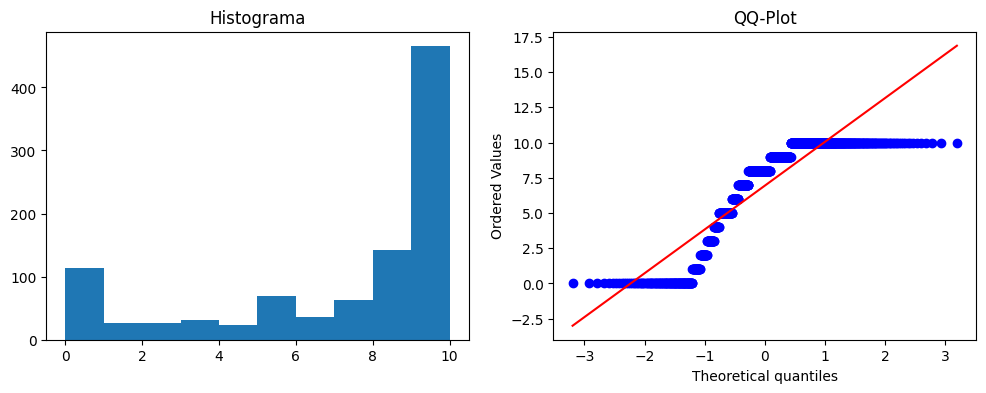

Média da amostra: 6.939
IC Bootstrap (95%): 6.725  a  7.153
p-valor Shapiro-Wilk: 0.0000 (não normal)


In [12]:
analyze_distribution_and_ci(sample['NPS'])

In [13]:
sample['NPS'].median()

8.0

Os dados não seguem distribuição normal com alta evidência estatística. p-value = 3.94 × 10⁻³³ (um número extremamente pequeno).
Regra geral:

* Se p > 0.05 = não rejeita normalidade

* Se p < 0.05 = rejeita normalidade

Média ≈ 6.939

É o valor central dos seus dados.

IC bootstrap (não-paramétrico): Não assume normalidade

IC Bootstrap (95%): 6.725  a  7.153

A média da amostra de NPS foi 6,939, indicando que, entre os clientes que responderam à pesquisa, a percepção média sobre os serviços do banco é positiva. Aplicando o método bootstrap para estimar a incerteza dessa média, obtivemos um intervalo de confiança de 95% entre 6,725 e 7,153. Isso significa que, com base na amostra, podemos afirmar com alta confiança que a média real de NPS da população de respondentes está dentro dessa faixa.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def monthly_nps_ci(sample, confidence=0.95, n_bootstrap=5000):
    """
    Calcula a média de NPS e IC bootstrap por mês e plota um gráfico de linhas.
    """
    months = sorted(sample['Month'].unique())
    means = []
    lower_ci = []
    upper_ci = []

    alpha = 1 - confidence

    for month in months:
        data = sample.loc[sample['Month'] == month, 'NPS'].values
        n = len(data)
        mean = np.mean(data)

        # Bootstrap
        boot_means = []
        for _ in range(n_bootstrap):
            sample_boot = np.random.choice(data, size=n, replace=True)
            boot_means.append(np.mean(sample_boot))

        lower = np.percentile(boot_means, (alpha/2) * 100)
        upper = np.percentile(boot_means, (1 - alpha/2) * 100)

        means.append(mean)
        lower_ci.append(lower)
        upper_ci.append(upper)

    # Plot
    plt.figure(figsize=(12,6))
    plt.plot(months, means, marker='o', label='Média NPS', color='blue')
    plt.fill_between(months, lower_ci, upper_ci, color='lightblue', alpha=0.4, label=f'IC {int(confidence*100)}%')
    plt.title("Média de NPS por Mês com Intervalo de Confiança (Bootstrap)")
    plt.xlabel("Mês")
    plt.ylabel("NPS")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.show()

    # Retornar tabela resumo
    df_summary = pd.DataFrame({
        'Month': months,
        'Mean_NPS': means,
        'CI_lower': lower_ci,
        'CI_upper': upper_ci
    })

    return df_summary


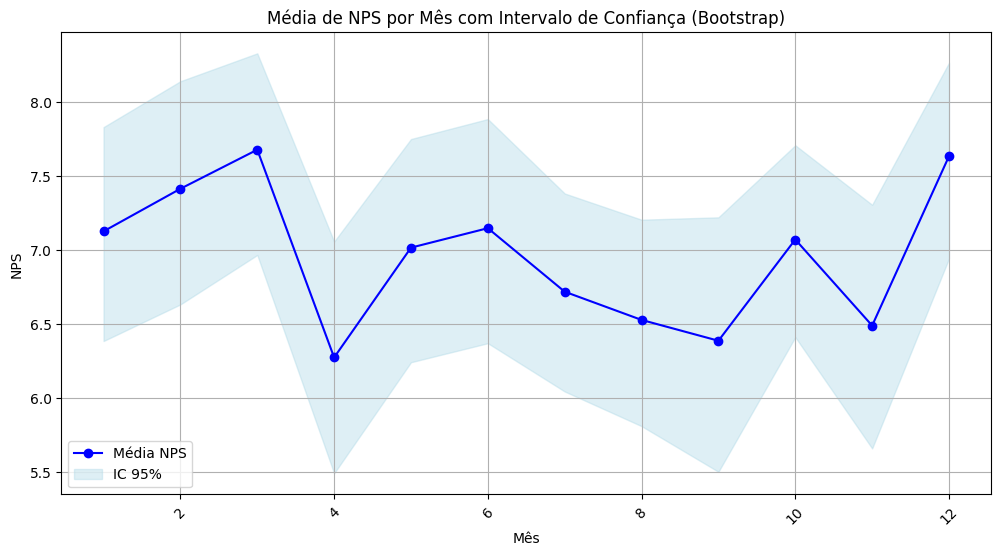

,Month,Mean_NPS,CI_lower,CI_upper
0,1,7.123457,6.382716,7.827160
1,2,7.410959,6.630137,8.136986
2,3,7.674699,6.963855,8.325301
3,4,6.271739,5.489130,7.054348
4,5,7.013333,6.239667,7.746667
5,6,7.144737,6.368092,7.881579
6,7,6.715789,6.042105,7.378947
7,8,6.525253,5.808081,7.202020
8,9,6.384615,5.500000,7.217949
9,10,7.068182,6.409091,7.704545


In [15]:
# Exemplo de uso:
df_summary = monthly_nps_ci(sample)
df_summary
